In [2]:
import pandas as pd

df = pd.read_csv(r"E:\HR_Analytics_Project\01_Dataset\employee_attrition_dataset_10000.csv")


In [3]:
## Feature Engineering 

df.dtypes

df_ml = df.copy()

df_ml = df_ml.drop('Employee_ID', axis=1)

In [4]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Select all categorical columns
categorical_columns = df_ml.select_dtypes(include=['object']).columns

# Apply Label Encoding
for col in categorical_columns:
    df_ml[col] = le.fit_transform(df_ml[col])

# Display first 5 rows
df_ml.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,58,1,2,0,3,5,7332,81,24,12,...,0,9,48,16,4,1,1,49,3,0
1,48,0,0,1,1,4,6069,55,18,7,...,1,9,57,10,4,1,1,25,1,0
2,34,0,1,3,3,4,11485,65,6,4,...,1,3,55,1,1,4,3,21,1,1
3,27,0,0,1,3,4,18707,28,12,9,...,0,9,53,2,3,4,1,46,2,0
4,40,1,1,1,0,1,16398,92,3,9,...,0,1,54,11,1,1,1,43,4,0


In [5]:
## Split the Data into Features (X) and Target (y)

# Features (Independent Variables)
X = df_ml.drop('Attrition', axis=1)

# Target Variable (Dependent Variable)
y = df_ml['Attrition']

# Check the shape
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 24)
Target Shape: (10000,)


In [6]:
## 

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shape of the datasets
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 24)
X_test : (2000, 24)
y_train: (8000,)
y_test : (2000,)


In [7]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
## Logistic Regression


from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

In [9]:
## Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", round(precision, 2))

# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", round(recall, 2))

# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", round(f1, 2))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 50.3 %
Precision: 0.21
Recall: 0.51
F1 Score: 0.29

Confusion Matrix:
[[799 793]
 [201 207]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.50      0.62      1592
           1       0.21      0.51      0.29       408

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.46      2000
weighted avg       0.68      0.50      0.55      2000



In [10]:
## Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [11]:
## Evaluate the Decision Tree Classifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy :", round(accuracy_score(y_test, dt_pred) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, dt_pred), 2))
print("Recall   :", round(recall_score(y_test, dt_pred), 2))
print("F1 Score :", round(f1_score(y_test, dt_pred), 2))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

Accuracy : 79.15 %
Precision: 0.15
Recall   : 0.0
F1 Score : 0.01

Confusion Matrix
[[1581   11]
 [ 406    2]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1592
           1       0.15      0.00      0.01       408

    accuracy                           0.79      2000
   macro avg       0.47      0.50      0.45      2000
weighted avg       0.66      0.79      0.71      2000



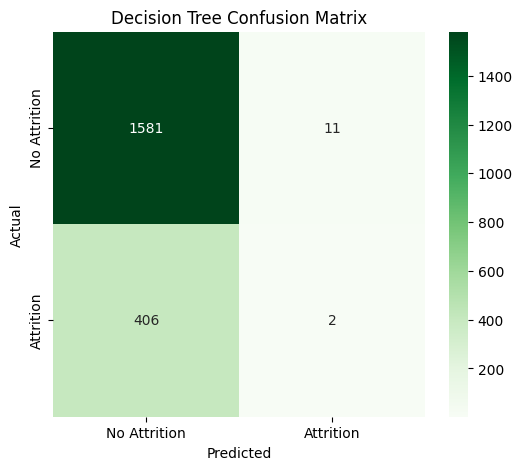

In [12]:
## Confusion Matrix 


import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Attrition','Attrition'],
    yticklabels=['No Attrition','Attrition']
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
## SHAP Analysis

import shap
explainer = shap.Explainer(log_model, X_train_scaled)

shap_values = explainer(X_test_scaled)

Background dataset has 8000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8000 when initializing the masker.


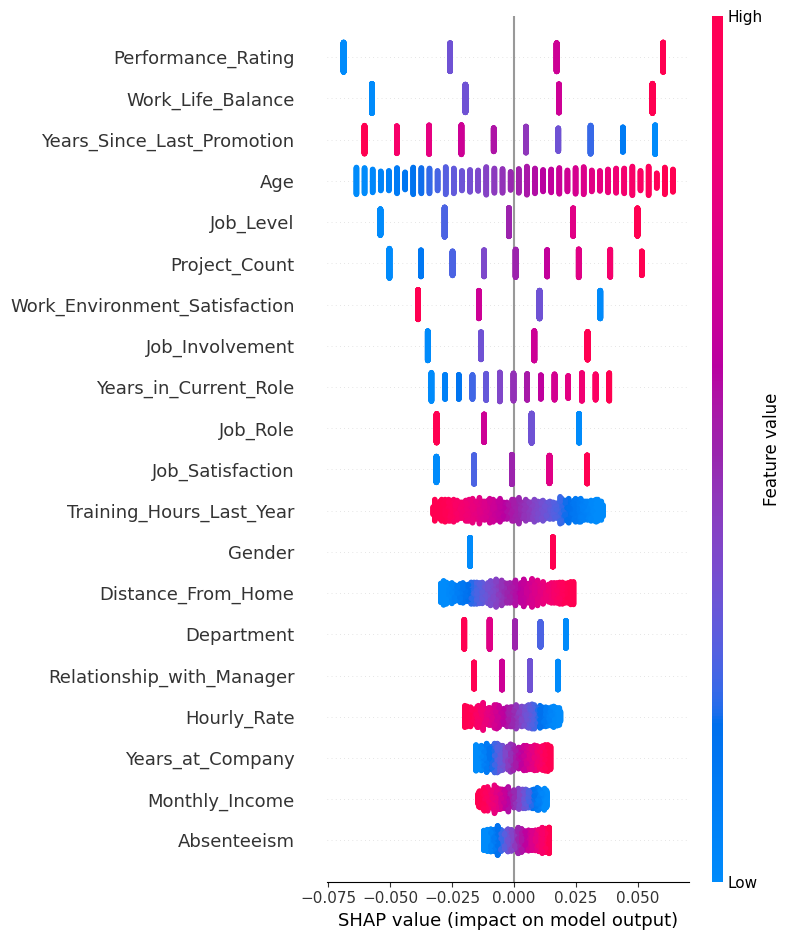

In [14]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

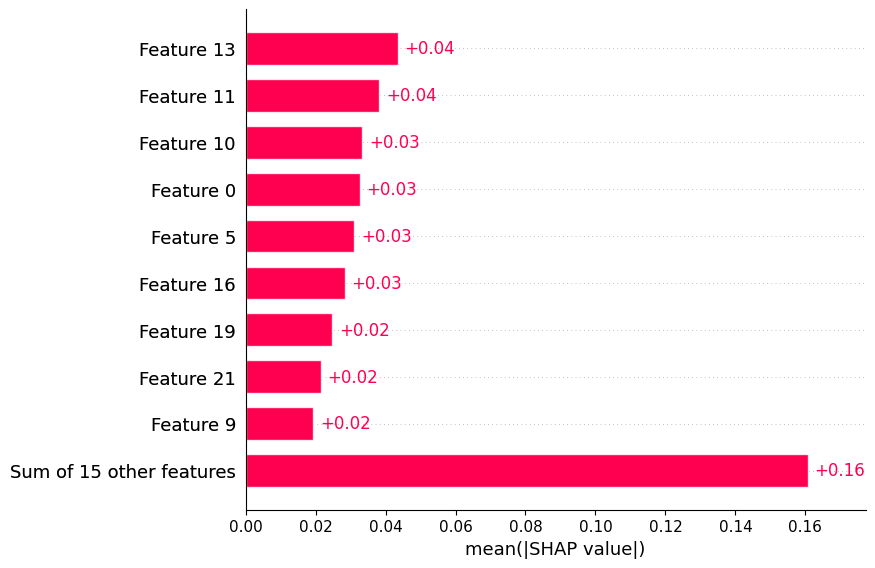

In [15]:
shap.plots.bar(shap_values)

In [16]:
df.to_csv("HR_Analytics_Final.csv", index=False)